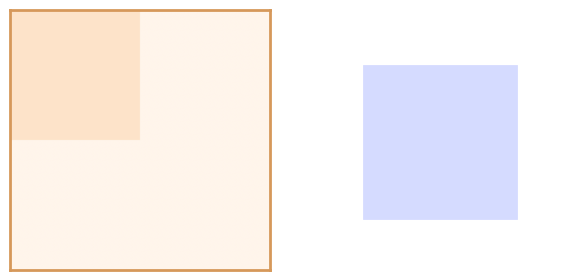

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch, FancyBboxPatch
import matplotlib.patheffects as patheffects

range_lim = 3
n_points = 500
x = np.linspace(-range_lim, range_lim, n_points)
y = np.linspace(-range_lim, range_lim, n_points)
X, Y = np.meshgrid(x, y)

uniform_pdf = np.zeros_like(X)
uniform_pdf[(X <= 0) & (Y >= 0)] = 1/9.0

n_samples = 100
ux = np.random.uniform(-3, 0, n_samples)
uy = np.random.uniform(0, 3, n_samples)

n_points2 = 500
n_samples2 = 100

# 1. Define the range for your points first
x_start, x_end = -1.5, 1.5
y_start, y_end = -1.5, 1.5

# 2. Generate points within that range
ux2 = np.random.uniform(x_start, x_end, n_samples2)
uy2 = np.random.uniform(y_start, y_end, n_samples2)

# 3. Create a grid that actually covers that range (with a little extra padding)
x2 = np.linspace(x_start, x_end, n_points2)
y2 = np.linspace(y_start, y_end, n_points2)
X2, Y2 = np.meshgrid(x2, y2)

# 4. Define the PDF logic using the SAME bounds as the points
uniform_pdf2 = np.zeros_like(X2)
mask = (X2 >= x_start) & (X2 <= x_end) & (Y2 >= y_start) & (Y2 <= y_end)
uniform_pdf2[mask] = 0  # Use a constant for uniform density


fig, axes = plt.subplots(1, 2, figsize=(6, 3), layout="constrained")
fig.set_constrained_layout_pads(h_pad=0.2, w_pad=0.2)

extent = [-range_lim, range_lim, -range_lim, range_lim]
extent2 = [x2.min(), x2.max(), y2.min(), y2.max()]

# --- LEFT PLOT: Colored Square Border ---
axes[0].imshow(uniform_pdf, extent=extent, origin='lower', cmap='Oranges', vmax=0.8)
#axes[0].scatter(ux, uy, s=6, alpha=1.0, color='#7f2704')

# Set border color and thickness
for spine in axes[0].spines.values():
    spine.set_edgecolor("#d6985a")
    spine.set_linewidth(2)

# --- RIGHT PLOT: Rounded Corners ---
axes[1].imshow(X=uniform_pdf2, extent=extent2, origin='lower', cmap="Purples", vmax=0.8)
#axes[1].scatter(ux2, uy2, s=6, alpha=1.0, color='#7f2704')
axes[1].set_facecolor("none") # Make axis transparent to see the patch

# 1. Hide the standard square spines
axes[1].axis('off') 

# Define the bounding box based on the data range
x_min, x_max = ux2.min(), ux2.max()
y_min, y_max = uy2.min(), uy2.max()

rounded_rect = FancyBboxPatch(
    (x_min, y_min), 
    x_max - x_min, y_max - y_min,
    boxstyle="square", # Padding adds the "white space" inside the border
    edgecolor= "#d5dbffff",#"#8b626fff",#"#7f92ffff", 
    facecolor="#d5dbffff",#"#dcbdc7c8",#"#d5dbffff",
    linewidth=2,
    zorder=0,
    clip_on=False
)

axes[1].add_patch(rounded_rect)

# Cleanup
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-range_lim, range_lim)
    ax.set_ylim(-range_lim, range_lim)
    ax.set_aspect('equal')

# Arrow
arrow_left = ConnectionPatch(
    xyA=(0.48, 0.75), coordsA=axes[0].transAxes,
    xyB=(0.23, 0.5), coordsB=axes[1].transAxes,
    arrowstyle="-|>", 
    mutation_scale=20, 
    linewidth=2, 
    color="#7f2704",
    shrinkA=5,
    shrinkB=5,
    zorder=1
)
#fig.add_artist(arrow_left)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(18, 6)) # Wider figure for 3 plots

# Surface Grid
x_s = np.linspace(-2, 2, 10)
y_s = np.linspace(-2, 2, 10)
X, Y = np.meshgrid(x_s, y_s)
Z_surf = np.zeros_like(X)

# Vector Grid
xv, yv, zv = np.meshgrid(np.linspace(-1.5, 1.5, 5), 
                         np.linspace(-1.5, 1.5, 5), 
                         np.linspace(-0.8, 0.8, 3))

# Define the three field directions (U, V, W)
fields = [
    (0, 0, 1),   # Positive (Up)
    (0, 0, -1),  # Negative (Down)
    (1, 0, 0)    # Zero (Side-to-side)
]
colors = ['blue', 'red', 'orangered']
surf_colors = ['blue', 'red', 'orange']

for i, (u_val, v_val, w_val) in enumerate(fields):
    ax = fig.add_subplot(131 + i, projection='3d')
    
    # Plot Surface
    ax.plot_surface(X, Y, Z_surf, alpha=0.2, color=surf_colors[i], edgecolor='black', lw=0.3)
    
    # Plot Field Vectors
    ax.quiver(xv, yv, zv, u_val, v_val, w_val, length=0.4, color=colors[i], arrow_length_ratio=0.3)
    
    # Show Normal Vector n (always pointing Up at 0,0,0)
    ax.quiver(0, 0, 0, 0, 0, 1.2, color='black', lw=3)
    
    # Title with Palatino
    math_label = "$\Phi_f > 0$" if i==0 else "$\Phi_f < 0$" if i==1 else "$\Phi_f = 0$"
    ax.set_title(f"{math_label}", fontsize=25, fontweight='bold', pad=10)
    
    ax.axis('off')
    ax.set_zlim(-1, 1)
    ax.view_init(elev=20, azim=30)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_evident_perturbations_non_zero_end():
    # 1. Setup the domain
    x = np.linspace(0, 1, 500)
    
    # 2. Define a complex, irregular base path y(x) that does NOT end at 0.
    # We choose y(0)=1 and y(1)=3.
    # y_base = initial_value + slope*x + oscillations
    y_base = 1 + 2*x + 0.5 * np.sin(2 * np.pi * x) + 0.2 * np.sin(5 * np.pi * x)
    
    # 3. Define the variation function eta(x).
    # It MUST be zero at boundaries x=0 and x=1.
    # We use a localized polynomial term, scaled up for visibility.
    eta = 10 * (x**2 * (1 - x)**2)
    
    # 4. Set large, "evident" epsilon magnitudes for the variation.
    epsilons = [-1.0, 1.0, 2.0]
    eps_strings = ["- ", "+ ", "+ 2"]
    colors = ['#d7191c', '#fdae61', '#2c7bb6'] # Red, Orange, Blue
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the irregular base path with prominence
    ax.plot(x, y_base, color='black', lw=3.5, label=r'$u(x)$', zorder=10)
    
    # Plot the perturbed paths y_new(x) = y(x) + eps * eta(x)
    for eps, eps_str, color in zip(epsilons, eps_strings, colors):
        y_perturbed = y_base + eps * eta
        ax.plot(x, y_perturbed, '--', color=color, alpha=0.9, lw=2,
                label=fr'$\tilde{{u}}(x) = u(x) {eps_str}\eta(x)$')
        
        # Draw displacement arrows at x=0.5 to highlight the shift magnitude
        shift_center = 0.5
        idx = np.abs(x - shift_center).argmin()
        ax.annotate('', xy=(x[idx], y_perturbed[idx]), xytext=(x[idx], y_base[idx]),
                     arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.8))

    # Styling the visualization
    ax.set_title(fr'Perturbations with test function $\eta$ and coefficient $\alpha = -1, 1, 2$', fontsize=13)
    ax.set_xlabel('$x$', fontsize=12)
    #ax.set_ylabel('$y(x)$', fontsize=12)
    
    # Define custom limits to encompass the entire shift
    ax.set_ylim(-0.5, 6.0) 
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Legend settings
    ax.legend(loc='upper left', frameon=True, fontsize=10)
    
    # Highlight fixed endpoints (non-zero: y(0)=1, y(1)=3)
    ax.scatter([0, 1], [y_base[0], y_base[-1]], color='black', s=100, zorder=11)
    #ax.text(0, y_base[0]+0.15, f'$({0}, {y_base[0]})$', ha='center', fontweight='bold')
    #ax.text(1, y_base[-1]+0.15, f'$({1}, {y_base[-1]})$', ha='center', fontweight='bold')
    
    #plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_evident_perturbations_non_zero_end()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_long_trail_cloud(num_points=180, tightness=0.25, trail_length=150):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 11)
    
    # 1. Define a much longer path (Full Square)
    path = []
    # Right
    for i in np.linspace(0.5, 9.5, 50): path.append((i, 9.5))
    # Down
    for i in np.linspace(9.5, 0.5, 50): path.append((9.5, i))
    # Left
    for i in np.linspace(9.5, 0.5, 50): path.append((i, 0.5))
    # Up
    for i in np.linspace(0.5, 9.5, 50): path.append((0.5, i))
    
    # Reverse so the "Head" is at the end of the movement
    path = path[::-1] 

    # 2. Limit the drawing to the desired 'trail_length'
    # We only take the first 'trail_length' points from the path
    visible_trail = path[:trail_length]

    for t in range(len(visible_trail)):
        pos_x, pos_y = visible_trail[t]
        
        # Calculate fade based on the trail_length, not the whole path
        alpha = (1.0 - (t / trail_length)) ** 1.5
        survival_rate = 1.0 - (t / trail_length)
        num_to_draw = int(num_points * survival_rate)
        
        x_vals = np.random.normal(pos_x, tightness, size=num_to_draw)
        y_vals = np.random.normal(pos_y, tightness, size=num_to_draw)

        # Force points to stay between 0 and 10
        x_vals = np.clip(x_vals, 0, 10)
        y_vals = np.clip(y_vals, 0, 10)

        ax.scatter(x_vals, y_vals, s=15, color='royalblue', alpha=alpha, edgecolors='none')

    # Formatting
    rect = plt.Rectangle((0, 0), 10, 10, linewidth=3, edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    ax.set_aspect('equal')
    plt.axis('off')
    plt.show()

# Increase trail_length to see more of the path history
plot_long_trail_cloud(tightness=1.9, trail_length=210, num_points=180)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup data
np.random.seed(42)
tasks = [fr'$\Psi_1$', fr'$\Psi_2$', fr'$\Psi_3$', fr'$\Psi_4$']
colors = ["#FFB570", "#CDA2BE", "#CCE5FF", "#FFCCCC"]
edgecolors = ["#CC6600", "#7E608B", "#5C83CF", "#A51D2D"]
# To avoid overlap, we create a grid of possible positions
# 15x15 grid gives 225 possible slots
grid_size = 15 
spacing = np.linspace(0.05, 0.95, grid_size)
gx, gy = np.meshgrid(spacing, spacing)
slots = np.vstack([gx.ravel(), gy.ravel()]).T

# Shuffle the slots so tasks are distributed randomly across the square
np.random.shuffle(slots)

plt.figure(figsize=(5, 5))
ax = plt.gca()

# Set the background color
ax.set_facecolor('#FFF9F0')

border_color = '#660033'
for spine in ax.spines.values():
    spine.set_edgecolor(border_color)
    spine.set_linewidth(2.5)

points_per_task = 23 # Total 160 points, plenty of room in 225 slots

# 2. Assign slots to tasks and add jitter
for i, task_name in enumerate(tasks):
    # Take a slice of the shuffled slots
    start_idx = i * points_per_task
    end_idx = (i + 1) * points_per_task
    task_slots = slots[start_idx:end_idx]
    
    # Add a tiny bit of random jitter so they aren't perfectly aligned
    # Jitter should be smaller than the distance between grid points
    jitter = (np.random.rand(*task_slots.shape) - 0.5) * 0.04
    coords = task_slots + jitter
    
    
    plt.scatter(coords[:, 0], coords[:, 1], 
                color=colors[i], label=task_name,
                edgecolors=edgecolors[i], s=80, linewidth=0.8, zorder=3)

# 3. Formatting
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')

#plt.title("Random Points per Task (Non-Overlapping)", fontsize=14, pad=15)
plt.xlabel(fr"$\varphi_a$", fontsize=18, color=border_color)
plt.ylabel(fr"$\varphi_b$", fontsize=18, color=border_color)

# Clean up axes
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Legend adjustment
leg = plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=18)
for i, text in enumerate(leg.get_texts()):
    text.set_color(edgecolors[i])


plt.tight_layout()
plt.show()